In [1]:

%load_ext autoreload
%autoreload 2

import os
#set project root
notebook_dir = os.getcwd()
print("Current notebook directory:", notebook_dir)

# Risali di un livello (notebook → DEEP-CHEMOMETRICS)
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))

# Imposta la working directory
os.chdir(project_root)
print("Working directory impostata su:", os.getcwd())


Current notebook directory: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/notebook
Working directory impostata su: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics


In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import torch 
import torch.utils.data as data_utils
import matplotlib.pyplot as plt
from torch import nn
from torch import optim
from torch.backends.mkl import verbose
from src import utils
from src.net import TMA_net
from src.training.training import Trainer
from src.utils.misc import TrainerConfig
from src.utils.misc import snv
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
from scipy.signal import savgol_filter
#from pyarrow import set_timezone_db_path


In [3]:
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))

CUDA available: True
Device count: 1
CUDA device name: NVIDIA GeForce RTX 3060


In [4]:
# load dataset Dario in .mat format

mango_original = pd.read_csv(r"data/dataset/Mango/NAnderson2020MendeleyMangoNIRData.csv", sep=',', header=0, index_col=0)
file = mango_original.copy()

data = sp.io.loadmat("data/dataset/Mango/mango_dm_full_outlier_removed2.mat")
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'DM_cal', 'DM_test', 'Sp_cal', 'Sp_test', 'wave', 'SP_all_test', 'SP_all_train'])


In [5]:
X_spectra_Dario_cal = data['Sp_cal']
print(X_spectra_Dario_cal.shape)

X_spectra_Dario_test = data['Sp_test']
print(X_spectra_Dario_test.shape)


# find wavelength from `data["wave"]` and convert them to strings
wave_names = [str(int(w)) for w in data["wave"].flatten()]

# Extract the original DataFrame with only wavelength of interest
X_original_df = mango_original[wave_names]
print(X_original_df.head())

#Convert in array NumPy
X_original = X_original_df.to_numpy()

print(X_original.shape)

(9914, 103)
(1448, 103)
          684       687       690       693       696       699       702  \
Set                                                                         
Cal -0.187572 -0.271236 -0.351005 -0.418628 -0.471548 -0.510750 -0.538847   
Cal -0.183253 -0.267107 -0.347271 -0.415050 -0.468100 -0.507443 -0.535537   
Cal -0.240969 -0.313623 -0.381965 -0.439224 -0.483448 -0.515665 -0.538356   
Cal -0.240610 -0.313087 -0.381506 -0.439003 -0.483402 -0.515663 -0.538322   
Cal  0.056370 -0.049269 -0.158413 -0.257995 -0.341550 -0.407727 -0.458308   

          705       708       711  ...       963       966       969  \
Set                                ...                                 
Cal -0.558357 -0.572195 -0.582111  ... -0.291061 -0.283766 -0.277665   
Cal -0.555035 -0.569050 -0.578928  ... -0.288114 -0.280321 -0.275603   
Cal -0.553933 -0.564771 -0.572177  ... -0.285849 -0.278140 -0.273570   
Cal -0.553813 -0.564752 -0.572182  ... -0.284648 -0.277382 -0.273996   
Cal 

In [6]:
#find row number of X_spectra_Dario_cal in X_original
row_numbers = []        
for i in range(X_spectra_Dario_cal.shape[0]):
    row_number = np.where((X_original == X_spectra_Dario_cal[i]).all(axis=1))[0]
    if row_number.size > 0:
        row_numbers.append(row_number[0])
    else:
        row_numbers.append(None)
# Stampa finale
if None in row_numbers:
    print("Cal: None in row")
else:
    print("Cal: All matched")

# Converti in array NumPy
row_numbers = np.array(row_numbers)

print("Row numbers for calibration spectra:", row_numbers, row_numbers.shape)

#find row number of X_spectra_Dario_test in X_original
row_numbers_test = []       
for i in range(X_spectra_Dario_test.shape[0]):
    row_number = np.where((X_original == X_spectra_Dario_test[i]).all(axis=1))[0]
    if row_number.size > 0:
        row_numbers_test.append(row_number[0])
    else:
        row_numbers_test.append(None)

# Converti in array NumPy
row_numbers_test = np.array(row_numbers_test)

# Stampa finale
if None in row_numbers_test:
    print("Test: None in row")
else:
    print("Test: All matched")

print("Row numbers for test spectra:", row_numbers_test, row_numbers_test.shape)

Cal: All matched
Row numbers for calibration spectra: [    0     1     2 ... 10240 10241 10242] (9914,)
Test: All matched
Row numbers for test spectra: [10243 10244 10245 ... 11688 11689 11690] (1448,)


In [7]:
# Extract from the original DataFrame only the rows corresponding to the calibration spectra of Dario
X_spectra_Dario_cal = mango_original.iloc[row_numbers, :]
# Extract from the original DataFrame only the rows corresponding to the test spectra of Dario
X_spectra_Dario_test = mango_original.iloc[row_numbers_test, :]

print(X_spectra_Dario_cal.shape)


(9914, 314)


In [8]:
# Find eventual replicates in the calibration spectra eand assign them a group label
# Replicate should have the same value of first 8 Dataframe columns
print(X_spectra_Dario_cal.shape)
print(list(X_spectra_Dario_cal.columns[:8]))
replicate_groups = X_spectra_Dario_cal.groupby(list(X_spectra_Dario_cal.columns[:8]),sort=False).ngroup()
print(replicate_groups[0:10]) # Print first 10 groups for brevity

(9914, 314)
['Season', 'Region', 'Date', 'Type', 'Cultivar', 'Pop', 'Temp', 'DM']
Set
Cal    0
Cal    0
Cal    1
Cal    1
Cal    2
Cal    2
Cal    3
Cal    3
Cal    4
Cal    4
dtype: int64


In [9]:
Ycal = data["DM_cal"]
Ytest = data["DM_test"]
Xcal = data["Sp_cal"]
Xtest = data["Sp_test"]

print("Total number of samples in the dataset: ", Xcal.shape[0] + Xtest.shape[0])
print("X and Y training set")
print(Xcal.shape)
print(Ycal.shape)
print("X and Y testing set")
print(Xtest.shape)
print(Ytest.shape)

Total number of samples in the dataset:  11362
X and Y training set
(9914, 103)
(9914, 1)
X and Y testing set
(1448, 103)
(1448, 1)


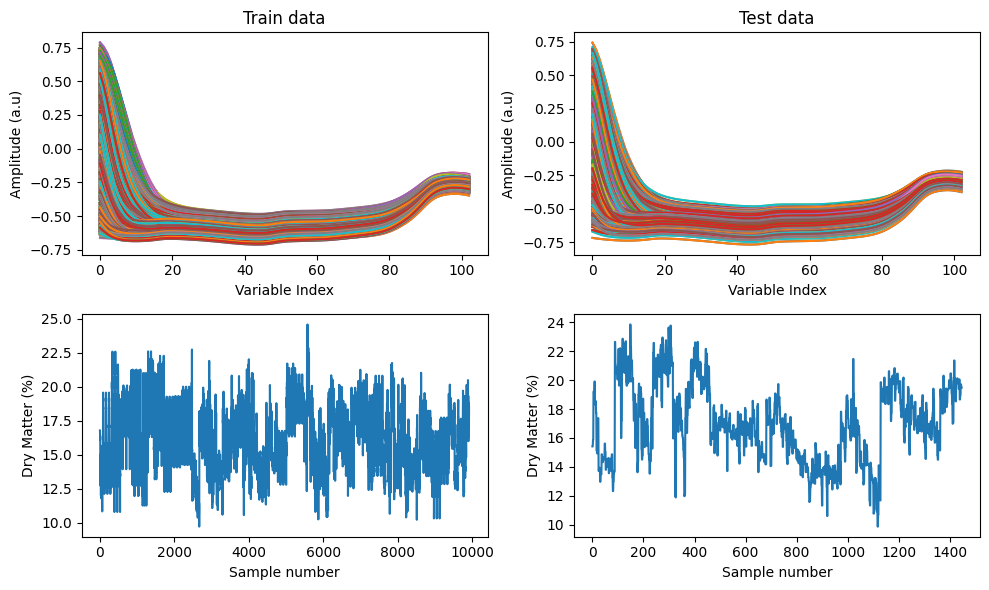

In [10]:
plt.figure(figsize=(10,6))
plt.subplot(221)
plt.title('Train data')
plt.plot(Xcal.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(222)
plt.title('Test data')
plt.plot(Xtest.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(223)
plt.plot(data['DM_cal'])
plt.ylabel('Dry Matter (%)')
plt.xlabel('Sample number')
plt.subplot(224)
plt.plot(data['DM_test'])
plt.ylabel('Dry Matter (%)')
plt.xlabel('Sample number')
plt.tight_layout()
plt.show()

In [ ]:
## Spliting the train set in x_cal e x_val

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42) # noooooooooooooo it should be 0,333
train_idx_rel, val_idx_rel = next(gss1.split(Xcal, y=None, groups=replicate_groups))


x_cal, x_val, y_cal, y_val = Xcal[train_idx_rel], Xcal[val_idx_rel], Ycal[train_idx_rel], Ycal[val_idx_rel]
## The wavelenghts for the X axis when we plot the spectra
x_scale=data['wave'].astype(np.float32).reshape(-1,1)


In [12]:

print('\n## Short resume of the dataset')

# Full Dataset
print('Data set dimensions ----------------------------')
print('Full Train set dims X Y = {}\t{}'.format(Xcal.shape, Ycal.shape))
print('Wavelengths number = {}'.format(x_scale.shape[0]))
print("")

# Calibration Dataset
years = pd.to_datetime(X_spectra_Dario_cal.iloc[train_idx_rel]['Date'], dayfirst=True).dt.year
print('Calibration set dims X Y = {}\t{}'.format(x_cal.shape, y_cal.shape))
print(f'Year range: from {years.min()} to {years.max()}')
print(
    'Cal: Uniques Season', np.unique(X_spectra_Dario_cal.iloc[train_idx_rel]['Season']),
    'Region', np.unique(X_spectra_Dario_cal.iloc[train_idx_rel]['Region']),
    'Type', np.unique(X_spectra_Dario_cal.iloc[train_idx_rel]['Type'])
)
print("")
# Validation Dataset
years = pd.to_datetime(X_spectra_Dario_cal.iloc[val_idx_rel]['Date'], dayfirst=True).dt.year
print('Validation set dims X Y = {}\t{}'.format(x_val.shape, y_val.shape))
print(
    'Val: Uniques Season', np.unique(X_spectra_Dario_cal.iloc[val_idx_rel]['Season']),
    'Region', np.unique(X_spectra_Dario_cal.iloc[val_idx_rel]['Region']),
    'Type', np.unique(X_spectra_Dario_cal.iloc[val_idx_rel]['Type'])
)
print("")
# Test Dataset
years = pd.to_datetime(X_spectra_Dario_test['Date'], dayfirst=True).dt.year
print('Test set dims X Y = {}\t{}'.format(Xtest.shape, Ytest.shape))
print(f'Year range: from {years.min()} to {years.max()}')
print(
    'Test: Uniques Season', np.unique(X_spectra_Dario_test['Season']),
    'Region', np.unique(X_spectra_Dario_test['Region']),
    'Type', np.unique(X_spectra_Dario_test['Type']))



## Short resume of the dataset
Data set dimensions ----------------------------
Full Train set dims X Y = (9914, 103)	(9914, 1)
Wavelengths number = 103

Calibration set dims X Y = (7928, 103)	(7928, 1)
Year range: from 2015 to 2018
Cal: Uniques Season [1 2 3] Region ['NT' 'QLD'] Type ['Hard Green' 'Ripen']

Validation set dims X Y = (1986, 103)	(1986, 1)
Val: Uniques Season [1 2 3] Region ['NT' 'QLD'] Type ['Hard Green' 'Ripen']

Test set dims X Y = (1448, 103)	(1448, 1)
Year range: from 2018 to 2019
Test: Uniques Season [4] Region ['NT' 'QLD'] Type ['Hard Green' 'Ripen']


Text(0.5, 0.98, 'Histogram of Y sets')

<Figure size 1200x600 with 0 Axes>

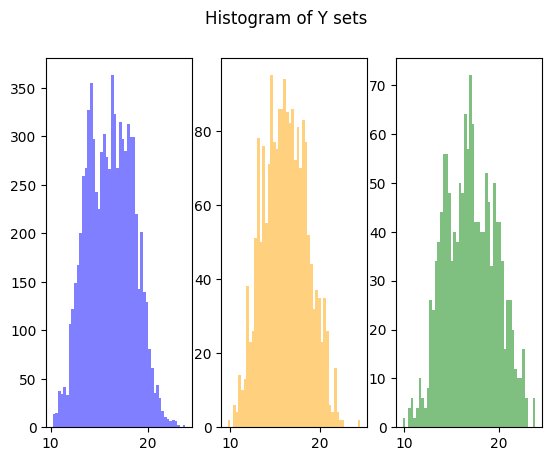

In [13]:
# plot histogram of each Y set
plt.figure(figsize=(12, 6))
fig, ax = plt.subplots(1, 3)
ax[0].hist(y_cal, bins=50, alpha=0.5, label='Ycal', color='blue')
ax[1].hist(y_val, bins=50, alpha=0.5, label='Yval', color='orange')
ax[2].hist(Ytest, bins=50, alpha=0.5, label='Ytest', color='green')
plt.suptitle('Histogram of Y sets')

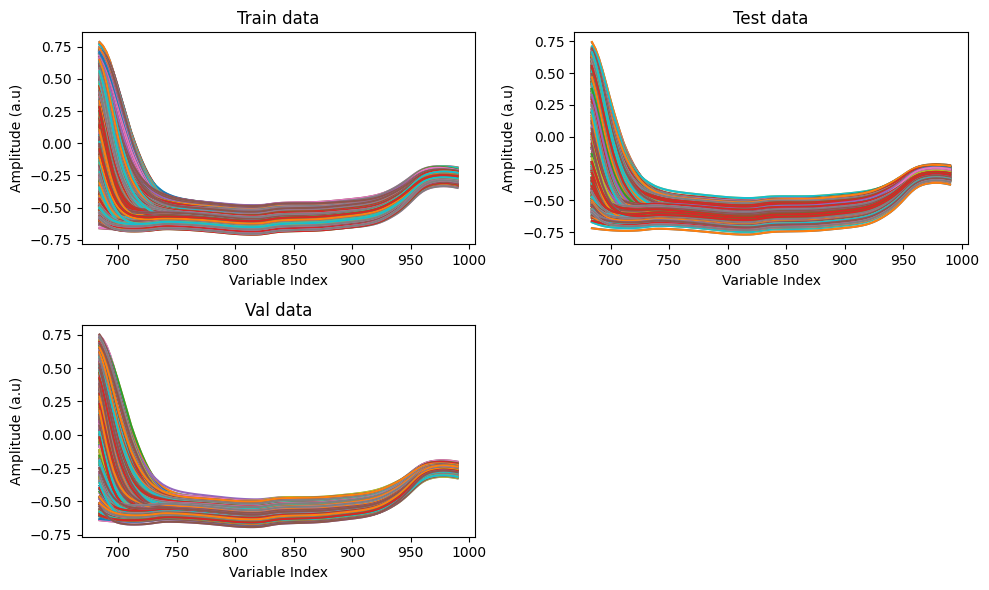

In [14]:
lmb = x_scale.copy()
plt.figure(figsize=(10,6))
plt.subplot(221)
plt.title('Train data')
plt.plot(lmb,x_cal.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(222)
plt.title('Test data')
plt.plot(lmb, Xtest.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(223)
plt.title('Val data')
plt.plot(lmb, x_val.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')

plt.tight_layout()
plt.show()

In [15]:
SG_Width = 13
SG_poly = 2

x_cal_snv = snv(x_cal)
x_val_snv = snv(x_val)
x_test_snv = snv(Xtest)

x_cal_SG1 = savgol_filter(x_cal, SG_Width, SG_poly, deriv = 1,axis=0)
x_val_SG1 = savgol_filter(x_val, SG_Width, SG_poly, deriv = 1,axis=0)
x_test_SG1 = savgol_filter(Xtest, SG_Width, SG_poly, deriv = 1,axis=0)


x_cal_SG2 = savgol_filter(x_cal, SG_Width, SG_poly, deriv = 2,axis=0)
x_val_SG2 = savgol_filter(x_val, SG_Width, SG_poly, deriv = 2,axis=0)
x_test_SG2= savgol_filter(Xtest, SG_Width, SG_poly, deriv = 2,axis=0)

x_cal_snv_SG1 = savgol_filter(x_cal_snv, SG_Width, SG_poly, deriv = 1,axis=0)
x_val_snv_SG1 = savgol_filter(x_val_snv, SG_Width, SG_poly, deriv = 1,axis=0)
x_test_snv_SG1 = savgol_filter(x_test_snv, SG_Width, SG_poly, deriv = 1,axis=0)


x_cal_snv_SG2 = savgol_filter(x_cal_snv, SG_Width, SG_poly, deriv = 2,axis=0)
x_val_snv_SG2 = savgol_filter(x_val_snv, SG_Width, SG_poly, deriv = 2,axis=0)
x_test_snv_SG2= savgol_filter(x_test_snv, SG_Width, SG_poly, deriv = 2,axis=0)

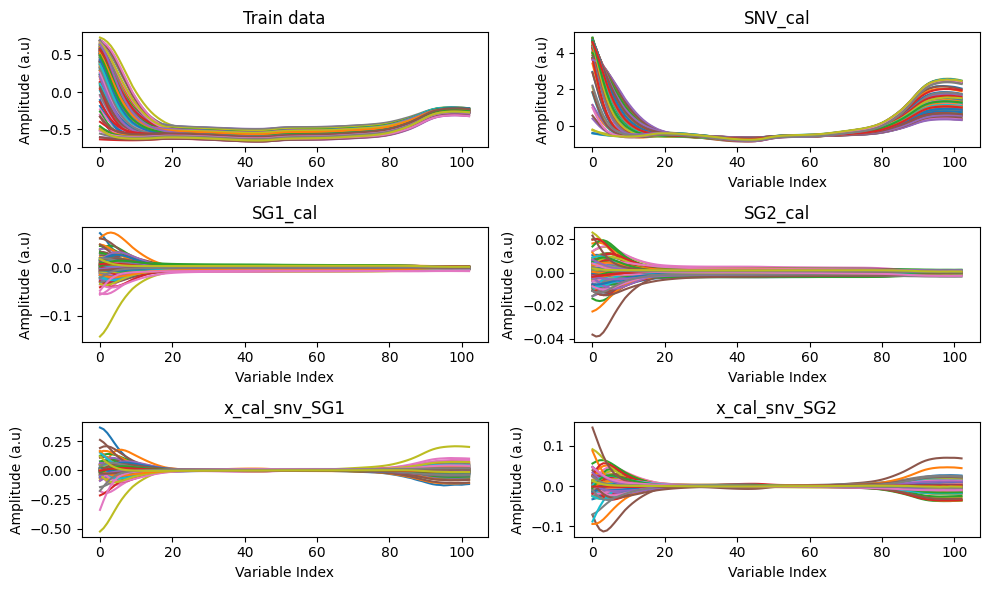

In [16]:
plt.figure(figsize=(10,6))
plt.subplot(321)
plt.title('Train data')
plt.plot(Xcal[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(322)
plt.title('SNV_cal')
plt.plot(x_cal_snv[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(323)
plt.title('SG1_cal')
plt.plot(x_cal_SG1[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(324)
plt.title('SG2_cal')
plt.plot(x_cal_SG2[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(325)
plt.title('x_cal_snv_SG1')
plt.plot(x_cal_snv_SG1[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(326)
plt.title('x_cal_snv_SG2')
plt.plot(x_cal_snv_SG2[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.tight_layout()
plt.show()


In [17]:
# Concatenate the preprocessed data
# unsqueeze the data to add a channel dimension
x_cal = np.expand_dims(x_cal, axis=2)
x_val = np.expand_dims(x_val, axis=2)
Xtest = np.expand_dims(Xtest, axis=2)

x_cal_snv = np.expand_dims(x_cal_snv, axis=2)
x_val_snv = np.expand_dims(x_val_snv, axis=2)
x_test_snv = np.expand_dims(x_test_snv, axis=2)

x_cal_SG1 = np.expand_dims(x_cal_SG1, axis=2)
x_val_SG1 = np.expand_dims(x_val_SG1, axis=2)
x_test_SG1 = np.expand_dims(x_test_SG1, axis=2)

x_cal_SG2 = np.expand_dims(x_cal_SG2, axis=2)
x_val_SG2 = np.expand_dims(x_val_SG2, axis=2)
x_test_SG2 = np.expand_dims(x_test_SG2, axis=2)

x_cal_snv_SG1 = np.expand_dims(x_cal_snv_SG1, axis=2)
x_val_snv_SG1 = np.expand_dims(x_val_snv_SG1, axis=2)
x_test_snv_SG1 = np.expand_dims(x_test_snv_SG1, axis=2)

x_cal_snv_SG2 = np.expand_dims(x_cal_snv_SG2, axis=2)
x_val_snv_SG2 = np.expand_dims(x_val_snv_SG2, axis=2)
x_test_snv_SG2 = np.expand_dims(x_test_snv_SG2, axis=2)
# Concatenate the data along the channel dimension
Xcal_concat = np.concatenate((x_cal, x_cal_snv, x_cal_SG1, x_cal_SG2, x_cal_snv_SG1, x_cal_snv_SG2), axis=2)
Xval_concat = np.concatenate((x_val, x_val_snv, x_val_SG1, x_val_SG2, x_val_snv_SG1, x_val_snv_SG2), axis=2)
Xtest_concat = np.concatenate((Xtest, x_test_snv, x_test_SG1, x_test_SG2, x_test_snv_SG1, x_test_snv_SG2), axis=2)
print("Xcal_concat shape:", Xcal_concat.shape)
print("Xval_concat shape:", Xval_concat.shape)
print("Xtest_concat shape:", Xtest_concat.shape) 

Xcal_concat shape: (7928, 103, 6)
Xval_concat shape: (1986, 103, 6)
Xtest_concat shape: (1448, 103, 6)


In [18]:
## Reshape according Torch training requirements
Xcal_concat = Xcal_concat.transpose(0, 2, 1)  # Transpose to (samples, channels, features)
Xval_concat = Xval_concat.transpose(0, 2, 1)  # Transpose to (samples, channels, features)
Xtest_concat = Xtest_concat.transpose(0, 2, 1)  # Transpose to (samples, channels, features)

## Check for dimensions
print('Data set dimensions ----------------------------')
print('Full Train set dims X Y = {}\t{}'.format(Xcal_concat.shape, Ycal.shape))
print('Test set dims X Y = {}\t{}'.format(Xtest_concat.shape, Ytest.shape))



Data set dimensions ----------------------------
Full Train set dims X Y = (7928, 6, 103)	(9914, 1)
Test set dims X Y = (1448, 6, 103)	(1448, 1)


In [19]:
# calculate mean and std per column

mean = np.mean(Xcal_concat, axis=0)
std = np.std(Xcal_concat, axis=0)
print("Mean shape:", mean.shape)
print("Std shape:", std.shape)


Mean shape: (6, 103)
Std shape: (6, 103)


In [20]:
x_cal_std = (Xcal_concat - mean) / std
x_val_std = (Xval_concat - mean) / std    
Xtest_concat_std = (Xtest_concat - mean) / std

In [21]:
# create trainer config
model_name ="Tpippo"
config = TrainerConfig(model_name = model_name)
config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=300,classification=False,max_loss_plot=20)
spec_dims = Xcal_concat.shape[2]
print("Spectral dimensions:", spec_dims)
print('SPectra channel:', Xcal_concat.shape[1])
print(config)

Spectral dimensions: 103
SPectra channel: 6
TrainerConfig(batch_size=1024, learning_rate=0.01, num_epochs=300, device=cuda, save_model=True,  classification=False, max_loss_plot=20,save_path=/home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/Tpippo)


In [22]:
# Convert np.array to Dataloader 
# add dt in loader 

cal = data_utils.TensorDataset(torch.Tensor(x_cal_std), torch.Tensor(y_cal))
cal_loader = data_utils.DataLoader(cal, batch_size=config.batch_size, shuffle=True)

val = data_utils.TensorDataset(torch.Tensor(x_val_std), torch.Tensor(y_val))
val_loader = data_utils.DataLoader(val, batch_size=config.batch_size, shuffle=False)

test_dt = data_utils.TensorDataset(torch.Tensor(Xtest_concat_std), torch.Tensor(Ytest))
test_loader = data_utils.DataLoader(test_dt, batch_size=config.batch_size, shuffle=False)


In [23]:
# import DoE experiment

Doe_run = pd.read_csv("data/dataset/Mango/DoE_TMA_Net/Optimize_TMA_net_step1_new_augmentedDopt.csv",delimiter=';',decimal=",").to_dict(orient='records')
print(Doe_run[26])



{'Exp No': 27, 'Exp Name': 'N27', 'Run Order': 9, 'Incl/Excl': 'Incl', 'kernel_size': 3, 'aggregation_mode': 'max', 'n_filters': 3, 'fc_dim1': 80, 'dropout': 0.3, 'MSE': nan, 'R2': nan}


In [24]:
# Run DoE experiment
results_table = []
for run in Doe_run:
    print(f"Running experiment: {run['Exp Name']}")    
    model_name = f"DOE_TMA_Mango_Dario_split_replicate_ok_{run['Exp Name']}"
    config = TrainerConfig(model_name = model_name)
    config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=1000,classification=False,max_loss_plot=20)

    model = TMA_net(
        input_dims=spec_dims,
        input_channel=x_cal_std.shape[1],
        kernel_size=run['kernel_size'],
        aggregation_mode=run['aggregation_mode'],
        n_filters=run['n_filters'],
        kernel_size_aggregation=3,
        fc1_dims=run['fc_dim1'],
        dropout=run['dropout'],
        out_dims=1
    )

    #print(model)

    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
    criterion = nn.MSELoss(reduction='mean')
    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=cal_loader,
        val_loader=val_loader,
        config=config,
        verbose=False,
    )
    train_losses, val_losses,val_r2_scores, final_path = trainer.train()
    results_table.append({
    "Exp Name": run["Exp Name"],
    "Final Val MSE": val_losses[-1].item(),
    "Final Val R²": np.mean(val_r2_scores[-1])
    })
    print(f"Training completed for {model_name}. Final path: {final_path}")


Running experiment: N1
Training completed for DOE_TMA_Mango_Dario_split_replicate_ok_N1. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N1_best.pth
Running experiment: N2
Training completed for DOE_TMA_Mango_Dario_split_replicate_ok_N2. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N2_best.pth
Running experiment: N3
Training completed for DOE_TMA_Mango_Dario_split_replicate_ok_N3. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N3_best.pth
Running experiment: N4
Training completed for DOE_TMA_Mango_Dario_split_replicate_ok_N4. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N4_best.

In [25]:
df_results = pd.DataFrame(results_table)
print(df_results)


   Exp Name  Final Val MSE  Final Val R²
0        N1       1.193815      0.799987
1        N2       0.741968      0.875690
2        N3       0.593459      0.900571
3        N4       0.555794      0.906882
4        N5       0.961815      0.838857
5        N6       0.688681      0.884618
6        N7       0.763947      0.872007
7        N8       1.721318      0.711609
8        N9       0.977561      0.836218
9       N10       0.517026      0.913377
10      N11       0.884924      0.851739
11      N12       1.331842      0.776862
12      N13       0.749369      0.874450
13      N14       1.001764      0.832163
14      N15       3.172939      0.468403
15      N16       0.577308      0.903277
16      N17       0.942269      0.842131
17      N18       9.516849     -0.594463
18      N19      27.689003     -3.639044
19      N20       0.808218      0.864590
20      N21       0.768622      0.871224
21      N22       0.714970      0.880213
22      N23      33.790154     -4.661238
23      N24     

In [26]:

df_results.to_csv("data/dataset/Mango/DoE_TMA_Net/DoE_results_MSE_R2.csv", index=False,sep=';', decimal=',')



TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(6, 6, kernel_size=(5,), stride=(1,), padding=same, groups=6)
  (aggregate_block): channel_mean()
  (fc1): Linear(in_features=103, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (norm): LayerNorm((6, 103), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Saving best model to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N27_best.pth
Epoch 1/1000 | Train Loss: 186.1954 | Val Loss: 44.5099 | Val Mean Metrics: -6.4572
Model saved at epoch 0 to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N27_best.pth
Epoch 2/1000 | Train Loss: 29.1627 | Val Loss: 13.4180 | Val Mean Metrics: -1.24

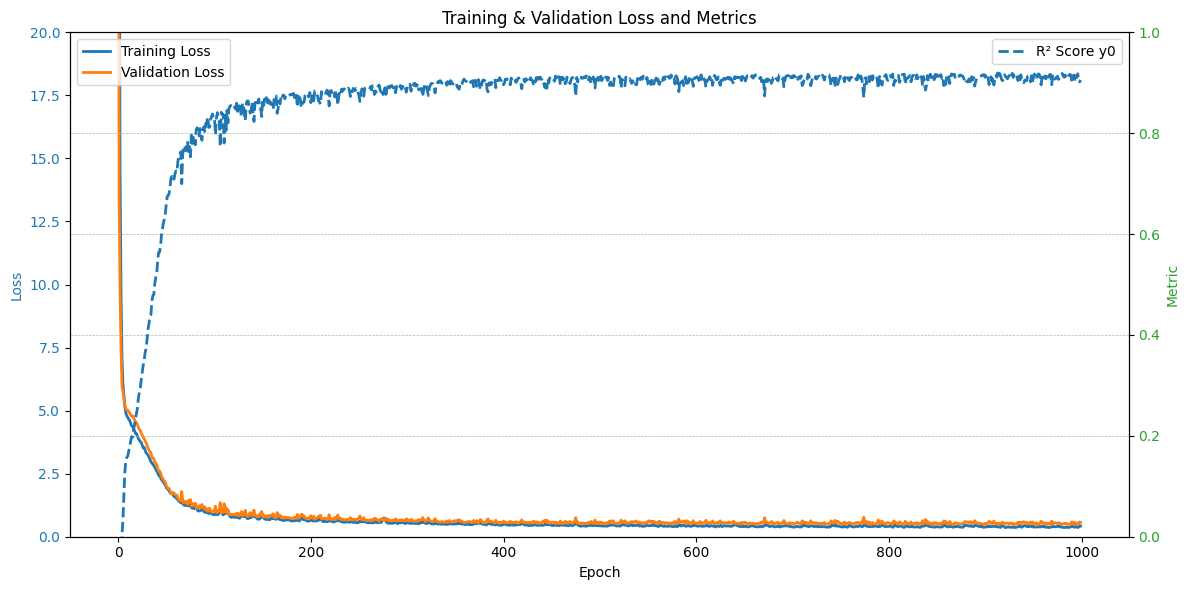

Training completed for TMA_Mango_Dario_split_replicate_ok_optimalconditions. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N27_best.pth


In [27]:

model_name = "TMA_Mango_Dario_split_replicate_ok_optimalconditions"
config.model_name = model_name
model = TMA_net(input_dims = spec_dims,
                input_channel = x_cal_std.shape[1],
                kernel_size = 5,
                aggregation_mode = "avg",
                n_filters = 1,
                kernel_size_aggregation = 3,
                fc1_dims = 128,
                dropout=0.1,
                out_dims=1)
config.num_epochs = 1000


optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
criterion = nn.MSELoss(reduction='none')
print(model)

trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, train_loader=cal_loader, val_loader=val_loader, config=config,verbose=True)

train_losses, val_losses,val_r2_scores, final_path = trainer.train()
print(f"Training completed for {model_name}. Final path: {final_path}")




tensor([0.4798])
CCC: 0.9316530989084058, R2: 0.8785064220428467, RMSEP: 0.9301630854606628
Shape of Y: (1448,), Shape of y_pred: (1448,)


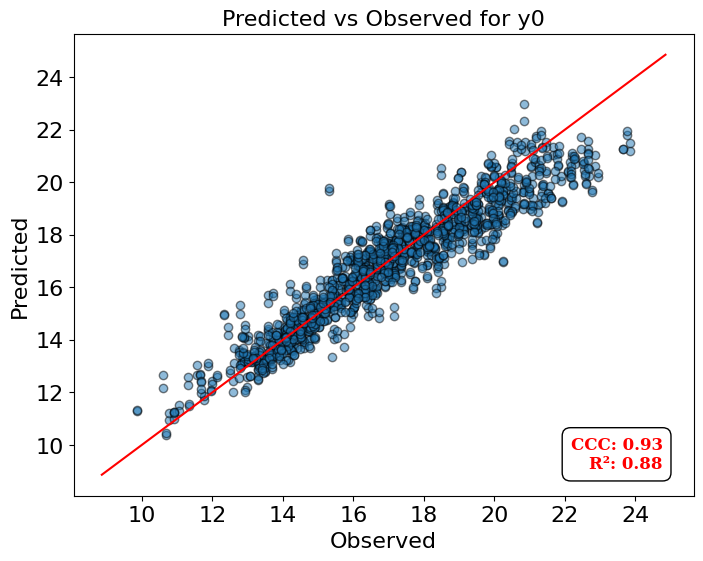

In [28]:
print(min(val_losses))
utils.test(model, final_path, test_loader,config)

In [29]:
total = 0
print("Nombre de paramètres par couche :")
for nom, param in model.named_parameters():
    if param.requires_grad:
        nb_params = param.numel()
        print(f"{nom}: {nb_params}")
        total += nb_params

print(f"\nNombre total de paramètres : {total}")

Nombre de paramètres par couche :
conv1d.weight: 30
conv1d.bias: 6
fc1.weight: 13184
fc1.bias: 128
fc2.weight: 8192
fc2.bias: 64
fc3.weight: 2048
fc3.bias: 32
norm.weight: 618
norm.bias: 618
output_layer.weight: 32
output_layer.bias: 1

Nombre total de paramètres : 24953


In [30]:

Xcal_reshape = Xcal_concat.reshape((Xcal_concat.shape[0], -1))
Xval_reshape = Xval_concat.reshape((Xval_concat.shape[0], -1))
Xtest_reshape = Xtest_concat.reshape((Xtest_concat.shape[0], -1))
mean_reshape = Xcal_reshape.mean(axis=0)
std_reshape = Xcal_reshape.std(axis=0)
print("mean_reshape = ", mean_reshape.shape)
print("std_reshape = ", std_reshape.shape)

mean_reshape =  (618,)
std_reshape =  (618,)


In [31]:
from src.net import Darionet



cal = data_utils.TensorDataset(torch.Tensor(Xcal_reshape), torch.Tensor(y_cal))
cal_loader = data_utils.DataLoader(cal, batch_size=config.batch_size, shuffle=True)

val = data_utils.TensorDataset(torch.Tensor(Xval_reshape), torch.Tensor(y_val))
val_loader = data_utils.DataLoader(val, batch_size=config.batch_size, shuffle=False)

test_dt = data_utils.TensorDataset(torch.Tensor(Xtest_reshape), torch.Tensor(Ytest))
test_loader = data_utils.DataLoader(test_dt, batch_size=config.batch_size, shuffle=False)


In [32]:
model_name = 'DarioNet'
config.model_name = model_name
model = Darionet(mean = mean_reshape, std = std_reshape ,filter_size = 45, reg_beta = 0.015, input_dims = Xcal_reshape.shape[-1],out_dims=1)
config.num_epochs = 1000


Darionet(
  (conv1): Conv1d(1, 1, kernel_size=(45,), stride=(1,), padding=same)
  (fc1): Linear(in_features=618, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
)
Saving best model to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N27_best.pth
Epoch 1/1000 | Train Loss: 11.4980 | Val Loss: 5.5010 | Val Mean Metrics: 0.0783
Model saved at epoch 0 to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N27_best.pth
Model saved at epoch 0 to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N27_best.pth
Epoch 2/1000 | Train Loss: 3.0736 | Val Loss: 2.3434 | Val M

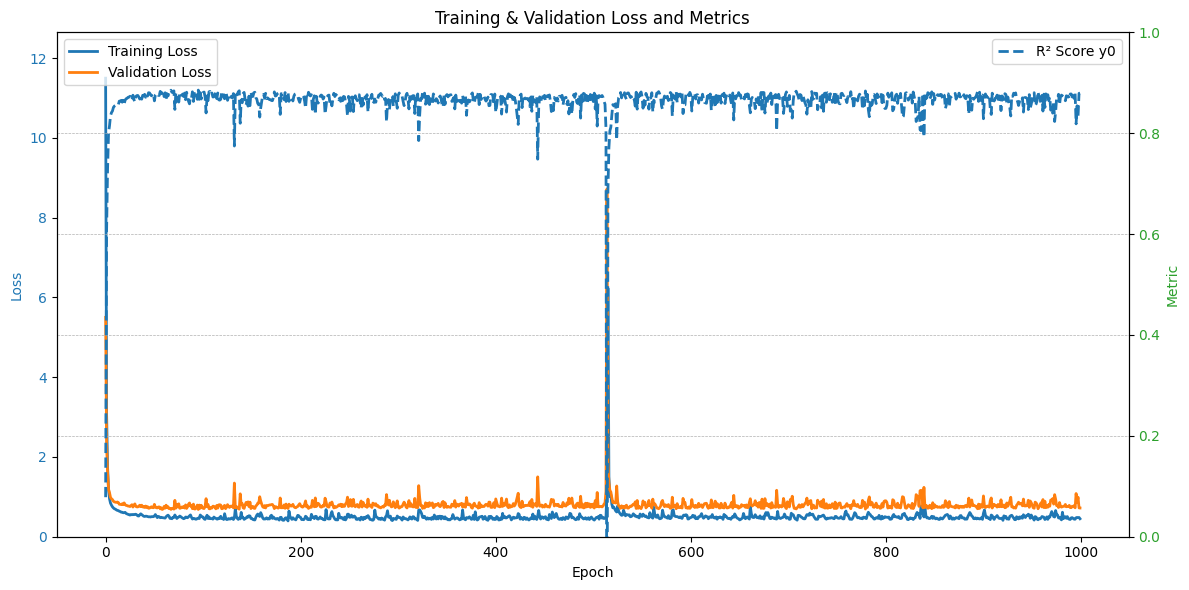

Training completed for DarioNet. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N27_best.pth


In [37]:
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.015)
criterion = nn.MSELoss(reduction='none')
print(model)

trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, train_loader=cal_loader, val_loader=val_loader, config=config,verbose=True)

train_losses, val_losses,val_r2_scores, final_path = trainer.train()
print(f"Training completed for {model_name}. Final path: {final_path}")



CCC: 0.9116593177777004, R2: 0.8418173789978027, RMSEP: 1.0613577365875244
Shape of Y: (1448,), Shape of y_pred: (1448,)


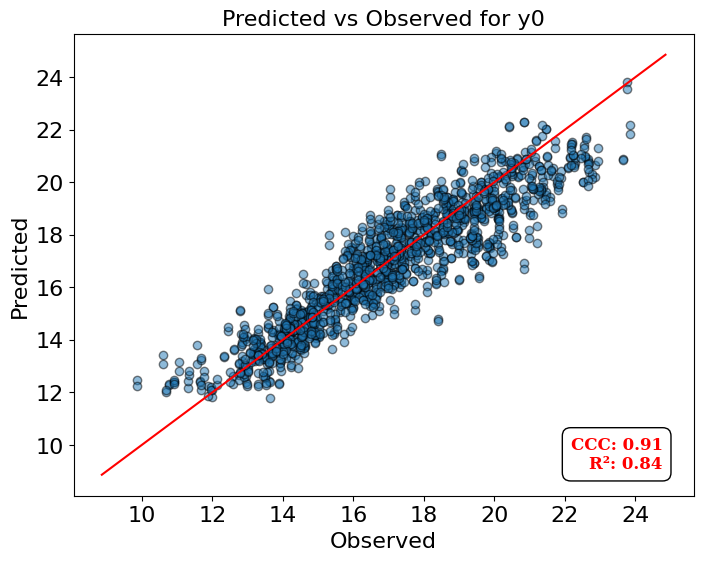

In [38]:
utils.test(model, final_path, test_loader,config)

In [39]:
total = 0
print("Nombre de paramètres par couche :")
for nom, param in model.named_parameters():
    if param.requires_grad:
        nb_params = param.numel()
        print(f"{nom}: {nb_params}")
        total += nb_params

print(f"\nNombre total de paramètres : {total}")

Nombre de paramètres par couche :
conv1.weight: 45
conv1.bias: 1
fc1.weight: 79104
fc1.bias: 128
fc2.weight: 8192
fc2.bias: 64
fc3.weight: 1024
fc3.bias: 16
output_layer.weight: 16
output_layer.bias: 1

Nombre total de paramètres : 88591
